# Content Portfolio Analysis
Loads scored data from data_modeling.ipynb and builds the segmentation and playbook visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [3]:
# Load scored data produced by data_modeling.ipynb
df = pd.read_csv("data/netflix_shows_scored.csv")
print(f"Loaded {len(df)} rows")
print(df[["name", "risk_score", "engagement_score"]].head())

Loaded 1485 rows
              name  risk_score  engagement_score
0  Stranger Things    0.071637          0.690909
1          Lucifer    0.031237          0.351398
2              Raw    0.015528          0.266357
3       HIS & HERS    0.002065          0.061636
4              CID    0.015501          0.064936


### Content Portfolio Segmentation
Two independent signals drive each show's portfolio action:
- **Risk tier**: XGBoost cancellation probability (Low < 0.35 / Medium 0.35â€“0.65 / High > 0.65)
- **Engagement tier**: percentile-based split at the median (top half = High, bottom half = Low)

Percentile thresholds are used for engagement because the score is heavily right-skewed (median = 0.007). A fixed numeric cutoff would classify 95%+ of shows as low-engagement and make the high-engagement segments nearly empty.

In [4]:
# Risk tier: fixed model-probability cutoffs
def risk_tier(score):
    if score < 0.35: # unlikely to be canceled
        return 'Low'
    elif score < 0.65:
        return 'Medium'
    else:
        return 'High' # highly likely to be canceled

In [5]:
# Engagement tier: percentile-based median split
engagement_median = df['engagement_score'].median()
def engagement_tier(score):
# scores each show in the top or bottom half based on engagement
    return 'High' if score >= engagement_median else 'Low'

In [6]:
df['risk_tier'] = df['risk_score'].apply(risk_tier)
df['engagement_tier'] = df['engagement_score'].apply(engagement_tier)

In [7]:
print("RISK TIER DISTRIBUTION")
print(df['risk_tier'].value_counts().reindex(['Low', 'Medium', 'High']))
print()

RISK TIER DISTRIBUTION
risk_tier
Low       1137
Medium     102
High       246
Name: count, dtype: int64



In [8]:
print("ENGAGEMENT TIER DISTRIBUTION")
print(df['engagement_tier'].value_counts())

ENGAGEMENT TIER DISTRIBUTION
engagement_tier
High    743
Low     742
Name: count, dtype: int64


In [9]:
# Set up portfolio action plan
conditions = [
    (df['risk_tier'] == 'Low')    & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'Low')    & (df['engagement_tier'] == 'Low'),
    (df['risk_tier'] == 'Medium') & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'Medium') & (df['engagement_tier'] == 'Low'),
    (df['risk_tier'] == 'High')   & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'High')   & (df['engagement_tier'] == 'Low'),
]

actions = [
    'Green-Light',
    'Renew Cautiously',
    'Renew Aggressively',
    'Renew Cautiously',
    'Harvest-and-End',
    'Sunset',
]
df['action_plan'] = np.select(conditions, actions, default='Review')

In [10]:
print("ACTION PLAN DISTRIBUTION")
print(df.groupby('action_plan').size())

ACTION PLAN DISTRIBUTION
action_plan
Green-Light           529
Harvest-and-End       148
Renew Aggressively     66
Renew Cautiously      644
Sunset                 98
dtype: int64


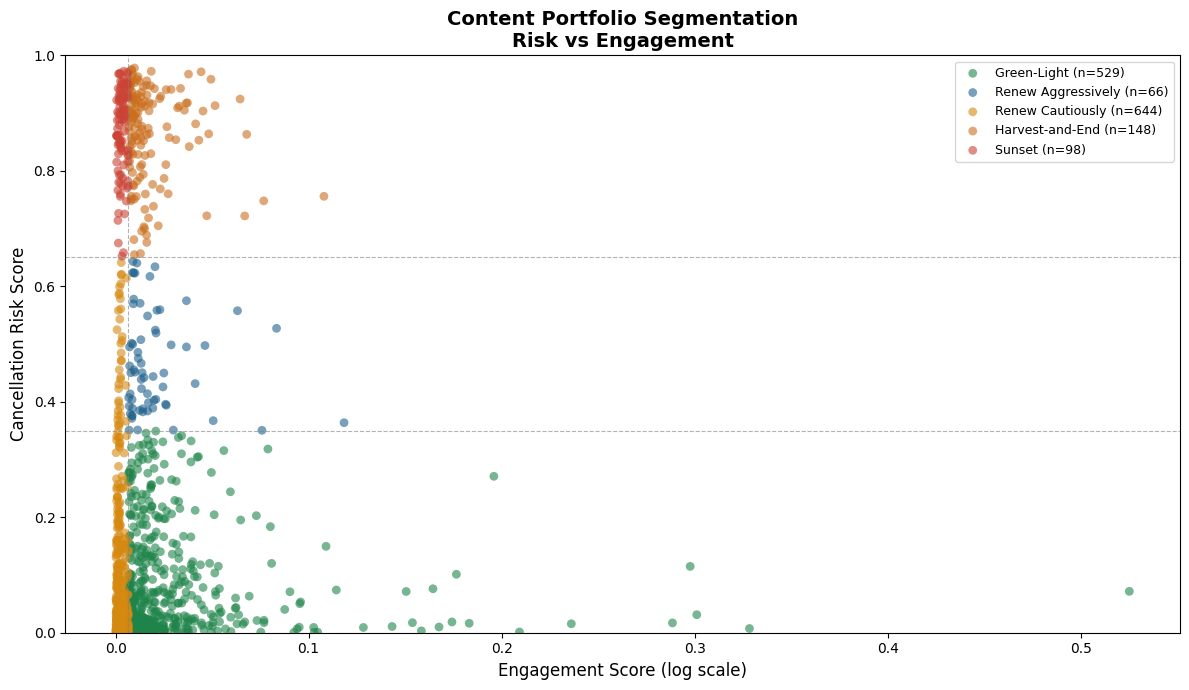

In [11]:
# color palette
ACTION_COLORS = {
    'Green-Light':        '#1e8449',
    'Renew Aggressively': '#1f618d',
    'Renew Cautiously':   '#d68910',
    'Harvest-and-End':    '#ca6f1e',
    'Sunset':             '#cb4335',
}

fig, ax = plt.subplots(figsize=(12, 7))

for action, color in ACTION_COLORS.items():
    subset = df[df['action_plan'] == action]
    ax.scatter(
        np.log1p(subset['engagement_score']),
        subset['risk_score'],
        c=color, label=f"{action} (n={len(subset)})",
        alpha=0.6, s=40, edgecolors='none'
    )

# Threshold lines
ax.axhline(0.35, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0.65, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(np.log1p(df['engagement_score'].median()),
           color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Engagement Score (log scale)', fontsize=12)
ax.set_ylabel('Cancellation Risk Score', fontsize=12)
ax.set_title('Content Portfolio Segmentation\nRisk vs Engagement', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)


plt.tight_layout()
plt.savefig('visualizations/11_portfolio_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# Summary counts per segment
matrix_data = df.groupby(['risk_tier', 'engagement_tier']).agg(
    count=('action_plan', 'count'),
    action=('action_plan', 'first'),
    example=('name', lambda x: x.iloc[0])
).reset_index()

print(matrix_data)


  risk_tier engagement_tier  count              action              example
0      High            High    148     Harvest-and-End  Alice in Borderland
1      High             Low     98              Sunset       The Waterfront
2       Low            High    529         Green-Light      Stranger Things
3       Low             Low    608    Renew Cautiously          Star Search
4    Medium            High     66  Renew Aggressively               Arcane
5    Medium             Low     36    Renew Cautiously                  Bet


In [13]:
# Define the grid layout: (row, col) positions
# Rows: risk tier top-to-bottom = High â†’ Medium â†’ Low (most urgent at top)
# Cols: engagement left-to-right = Low â†’ High

GRID_POSITIONS = {
    ('High',   'Low'):  (0, 0),
    ('High',   'High'): (0, 1),
    ('Medium', 'Low'):  (1, 0),
    ('Medium', 'High'): (1, 1),
    ('Low',    'Low'):  (2, 0),
    ('Low',    'High'): (2, 1),
}

# Build a lookup: (risk, engagement) â†’ row data
segment_lookup = {
    (row['risk_tier'], row['engagement_tier']): row
    for _, row in matrix_data.iterrows()
}

# Preview: confirm each segment maps to the right cell
for (risk, eng), (r, c) in GRID_POSITIONS.items():
    seg = segment_lookup[(risk, eng)]
    print(f"[row {r}, col {c}]  {risk:6} risk / {eng:4} engagement  â†’  {seg['action']:22}  n={seg['count']}")


[row 0, col 0]  High   risk / Low  engagement  â†’  Sunset                  n=98
[row 0, col 1]  High   risk / High engagement  â†’  Harvest-and-End         n=148
[row 1, col 0]  Medium risk / Low  engagement  â†’  Renew Cautiously        n=36
[row 1, col 1]  Medium risk / High engagement  â†’  Renew Aggressively      n=66
[row 2, col 0]  Low    risk / Low  engagement  â†’  Renew Cautiously        n=608
[row 2, col 1]  Low    risk / High engagement  â†’  Green-Light             n=529


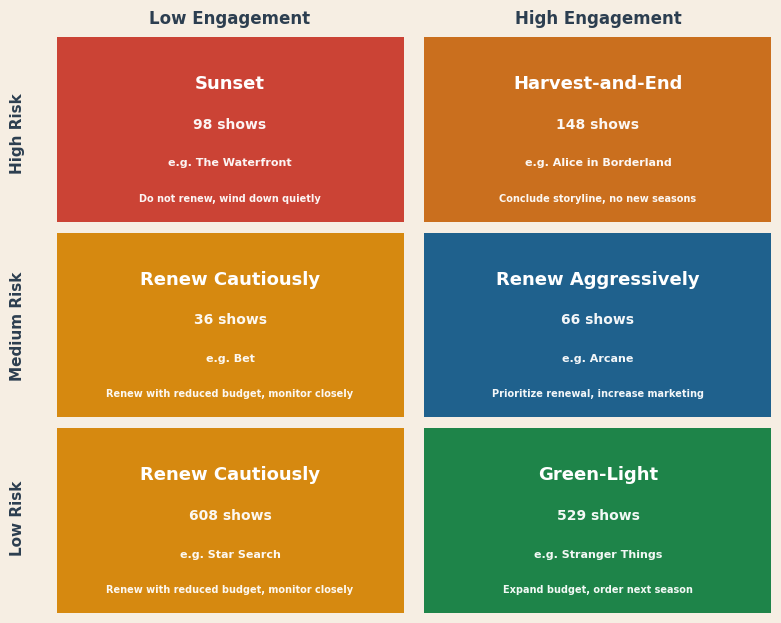

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
fig.patch.set_facecolor('#F6EEE3')

# Layout defined once â€” change these to adjust spacing
LAYOUT = dict(left=0.05, right=0.60, top=0.80, bottom=0.08, hspace=0.06, wspace=0.06)
plt.subplots_adjust(**LAYOUT)
grid_center = (LAYOUT['left'] + LAYOUT['right']) / 2

# Compute row label y-positions from layout so they always align
total_h = LAYOUT['top'] - LAYOUT['bottom']
row_h   = total_h / 3
row_centers = [
    LAYOUT['top'] - row_h * 0.5,   # High Risk row
    LAYOUT['top'] - row_h * 1.5,   # Medium Risk row
    LAYOUT['top'] - row_h * 2.5,   # Low Risk row
]

ACTION_DESCRIPTORS = {
    'Green-Light':        'Expand budget, order next season',
    'Renew Aggressively': 'Prioritize renewal, increase marketing',
    'Renew Cautiously':   'Renew with reduced budget, monitor closely',
    'Harvest-and-End':    'Conclude storyline, no new seasons',
    'Sunset':             'Do not renew, wind down quietly',
}


# Column headers
for c, label in enumerate(['Low Engagement', 'High Engagement']):
    axes[0, c].set_title(label, fontsize=12, fontweight='bold', color='#2c3e50', pad=10)

# Row headers â€” positions derived from layout, so always in whitespace
for label, y in zip(['High Risk', 'Medium Risk', 'Low Risk'], row_centers):
    fig.text(0.02, y, label, ha='center', va='center',
             fontsize=11, fontweight='bold', color='#2c3e50', rotation=90)

for (risk, eng), (r, c) in GRID_POSITIONS.items():
    ax = axes[r, c]
    seg = segment_lookup[(risk, eng)]
    color = ACTION_COLORS[seg['action']]

    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(0.5, 0.75, seg['action'],
            ha='center', va='center', transform=ax.transAxes,
            fontsize=13, fontweight='bold', color='white')
    ax.text(0.5, 0.53, f"{seg['count']} shows",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='white', alpha=0.95)
    ax.text(0.5, 0.32, f"e.g. {seg['example']}",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=8, fontweight='bold', color='white', alpha=0.95)
    ax.text(0.5, 0.13, ACTION_DESCRIPTORS[seg['action']],
        ha='center', va='center', transform=ax.transAxes,
        fontsize=7, fontweight='bold', color='white', alpha=0.95)

plt.savefig('visualizations/12_portfolio_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
